# Point 3, Decision Support, Fairness Correction


## What This Notebook Does

Point 3's second track, folded into training rather than only measured
after the fact. 07-ciml, lesson 2, Lagrangian Approaches for Constraint
Injection, reframes fairness as a constraint on training:

$$
\operatorname{argmin}_{\theta} \mathbb{E}\left[ L(y, f(x, \theta))\right] +\lambda \max\left(0, \operatorname{DIDI}(f(x, \theta)) - \varepsilon \right)
$$

Three small networks predict RISK_SCORE from the same biomarkers the
attribution notebook uses, with PTGENDER and PTEDUCAT_BUCKET added as
inputs, since the Lagrangian penalty needs to know each row's protected
group at training time even though the group itself is not the
prediction target. Method one is unconstrained, the accuracy ceiling the
other two are judged against. Method two, CstDIDIRegressor, follows
util.CstDIDIModel with a fixed multiplier lambda chosen by hand. Method
three, LagDualDIDIRegressor, follows util.LagDualDIDIModel, where lambda
is itself learned via gradient ascent, which the lesson demonstrates
reaches the same fairness level with noticeably better accuracy than
guessing a fixed lambda.

This notebook is one of five standalone, single purpose notebooks
spread across notebooks/decision_support, notebooks/fairness, and
notebooks/pipeline, each comparable to the others because every one loads the same
final.csv, applies the same forward fill, builds the same placeholder
RISK_SCORE, and splits by patient the same way, with random_state=42,
then appends one standardized summary row per split to the shared
results/decision_support/approach_comparison.csv. comparison.ipynb reads that one
file and draws conclusions across all five, grouped by the kind of
question they answer rather than forced into one single ranking. See
NOTES.md for the reasoning behind this track. decision_walkthrough.ipynb,
the original single notebook version of all three tracks, now lives in
notebooks/archive, kept for reference rather than as required reading.

Both Lagrangian classes now fix Keras's own random seed before building
their network, inside util/decision_util.py, so the numbers in this
notebook are reproducible across reruns, unlike an earlier version of
this project's fairness section, where the same cell could report a
noticeably different dual lambda from one run to the next.

A correction folded in after this notebook was first built, worth stating up front. RISK_SCORE below used to come entirely from du.placeholder_risk_score, a synthetic stand in for a real predictive signal that did not exist yet. That signal exists now. Point 2's hazard_model_1 has a per patient score, exported by notebooks/pipeline/final_pipeline.ipynb to results/decision_support/hazard_estimate_leo_keyed.csv, and Point 1's ANOMALY_SCORE from pca_hi_trajectory.py is real as well. Both only cover part of final.csv, so this notebook now restricts to the same 1126 patient common subset final_pipeline.ipynb computes and validates, rather than the full native population the paragraph above describes for the other four notebooks in this comparison. RISK_SCORE below is Point 2's hazard probability where it exists, falling back to the placeholder for the remaining rows, the same chained score final_pipeline.ipynb calls RISK_SCORE_AFTER. This notebook's own population and target both differ from the shared setup description above as a result, worth keeping in mind when comparison.ipynb reads its numbers next to the other four.


In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)

## Shared Setup

This block, and the one right after it, follow the same shared setup every
approach_*.ipynb notebook for this stage starts from, the same forward filled
final.csv and the same subject level split with random_state=42. What happens
between those two steps differs here on purpose now. RISK_SCORE below is the real
chained score final_pipeline.ipynb builds, not the placeholder every other approach
notebook still uses, and the population is narrowed first to the patients that real
score actually covers. See NOTES.md for the detailed reasoning behind the shared
steps, this notebook focuses on one approach only and keeps that shared context
brief.


In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

# SWAP POINT, now done. Point 1's ANOMALY_SCORE and Point 2's hazard_model_1
# score both only cover part of final.csv, so the population below is
# restricted to the same common subset notebooks/pipeline/final_pipeline.ipynb
# computes and validates, the largest population that actually has both real
# signals, rather than mixing a real score with the placeholder across a
# wider population that would not compare evenly with itself.
anomaly_path = os.path.join('..', '..', 'notebooks', 'anomaly_detection', 'method_b_autoencoder_hi', 'pca_hi_trajectories_keyed.csv')
leo_hazard_path = os.path.join(results_path, 'hazard_estimate_leo_keyed.csv')
gio_rids = set(pd.read_csv(anomaly_path)['RID'].unique())
leo_hazard_out = pd.read_csv(leo_hazard_path)

common_rids = gio_rids & set(leo_hazard_out['RID'].unique()) & set(data['RID'].unique())
print(f'Common subset, same one final_pipeline.ipynb computes: {len(common_rids)} patients')

data = data[data['RID'].isin(common_rids)].copy()
data = data.merge(leo_hazard_out[['RID', 'VISCODE2_norm', 'HAZARD_SCORE_LEO']], on=['RID', 'VISCODE2_norm'], how='left')

data['RISK_SCORE'] = du.placeholder_risk_score(data)
hazard_coverage = data['HAZARD_SCORE_LEO'].notna().mean()
data['RISK_SCORE'] = data['HAZARD_SCORE_LEO'].fillna(data['RISK_SCORE'])
print(f'Real hazard_model_1 coverage on this subset: {hazard_coverage:.1%} of rows, '
      f'the rest fall back to the placeholder, same fallback final_pipeline.ipynb uses')

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')


Common subset, same one final_pipeline.ipynb computes: 1126 patients
Real hazard_model_1 coverage on this subset: 64.1% of rows, the rest fall back to the placeholder, same fallback final_pipeline.ipynb uses
Train, 5713 rows, 844 patients
Test,  1972 rows, 282 patients


## Disparate Treatment, and DIDI

PTGENDER, PTEDUCAT, and PTMARRY are all clean and complete in final.csv,
none of them are used as a model input outside this Lagrangian track, per
07-ciml's own point that removing a protected attribute from the inputs
does not prevent disparate treatment through its correlates, measuring
the output is the only way to actually check this.

$$
\text{DIDI}_r = \sum_{j \in J_p} \sum_{v \in D_{j}} \left|\frac{1}{m} \sum_{i=1}^m y_i - \frac{1}{|I_{j,v}|} \sum_{i \in I_{j,v}} y_{i}\right|
$$


In [3]:
def make_protected(df):
    return {
        'PTGENDER': (1, 2),
        'PTEDUCAT_BUCKET': (0, 1),
        'PTMARRY': tuple(sorted(df['PTMARRY'].dropna().unique())),
    }

train_df = train_df.copy()
test_df = test_df.copy()
train_df['PTEDUCAT_BUCKET'] = du.bucket_educat(train_df['PTEDUCAT'], split_at=16)
test_df['PTEDUCAT_BUCKET'] = du.bucket_educat(test_df['PTEDUCAT'], split_at=16)

## Checking The Biomarkers Themselves, Not Only The Model's Output

The section above already states, following 07 ciml directly, that removing a protected attribute from a model's inputs does not prevent disparate treatment through its correlates. Every risk_factors notebook in decision_support acts on exactly that principle, PTGENDER, PTEDUCAT, and PTMARRY are kept out of feature_cols and slope_cols entirely, but nothing in this project so far actually checks whether the eight biomarkers those notebooks do use as inputs, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM, SUMMARY_SUVR, ABETA_RATIO, TAU, PTAU, and AGE, are themselves correlated with one of the three excluded attributes. DIDI below audits RISK_SCORE, this checks the biomarkers directly, one step earlier in the pipeline, before any model has been fit on them at all.

biomarker_protected_association in util/decision_util.py runs a one way ANOVA for each biomarker against each protected attribute, PTGENDER as is, PTMARRY as is, and PTEDUCAT already bucketed the same way the Lagrangian section below needs it. Eta squared reports how much of that biomarker's own variance the protected attribute explains, on a scale from 0 to 1, comparable across every pair regardless of how many groups that attribute has.

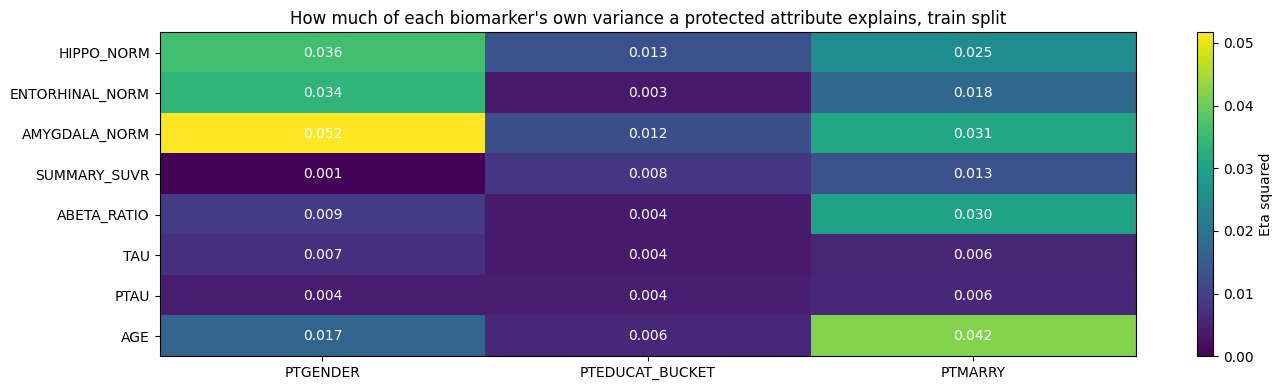

          biomarker        protected  eta_squared       p_value  n_groups
0     AMYGDALA_NORM         PTGENDER     0.051673  7.398235e-68         2
1               AGE          PTMARRY     0.041792  2.056529e-51         5
2        HIPPO_NORM         PTGENDER     0.036090  1.444143e-47         2
3   ENTORHINAL_NORM         PTGENDER     0.033890  9.982533e-45         2
4     AMYGDALA_NORM          PTMARRY     0.030720  1.877876e-37         5
5       ABETA_RATIO          PTMARRY     0.029674  5.714957e-08         4
6        HIPPO_NORM          PTMARRY     0.025096  2.280889e-30         5
7   ENTORHINAL_NORM          PTMARRY     0.017523  6.241529e-21         5
8               AGE         PTGENDER     0.016795  9.141763e-23         2
9        HIPPO_NORM  PTEDUCAT_BUCKET     0.013107  3.956316e-18         2
10     SUMMARY_SUVR          PTMARRY     0.012901  8.803018e-12         5
11    AMYGDALA_NORM  PTEDUCAT_BUCKET     0.012440  2.793593e-17         2
12      ABETA_RATIO         PTGENDER  

In [4]:
protected_check_cols = ['PTGENDER', 'PTEDUCAT_BUCKET', 'PTMARRY']
biomarker_check_cols = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU', 'AGE',
]

biomarker_association = du.biomarker_protected_association(train_df, biomarker_check_cols, protected_check_cols)
biomarker_association_pivot = biomarker_association.pivot(index='biomarker', columns='protected', values='eta_squared')
biomarker_association_pivot = biomarker_association_pivot.reindex(biomarker_check_cols)[protected_check_cols]

plt.figure(figsize=figsize)
plt.imshow(biomarker_association_pivot.values, aspect='auto', cmap='viridis', vmin=0)
plt.colorbar(label='Eta squared')
plt.xticks(range(len(protected_check_cols)), protected_check_cols)
plt.yticks(range(len(biomarker_check_cols)), biomarker_check_cols)
plt.title('How much of each biomarker\'s own variance a protected attribute explains, train split')
for i in range(len(biomarker_check_cols)):
    for j in range(len(protected_check_cols)):
        value = biomarker_association_pivot.values[i, j]
        if not np.isnan(value):
            plt.text(j, i, f'{value:.3f}', ha='center', va='center', color='white' if value < 0.5 else 'black')
plt.tight_layout()
plt.show()

biomarker_association.sort_values('eta_squared', ascending=False).reset_index(drop=True)

**Read eta squared the same way R squared is read elsewhere in this project, the fraction of a biomarker's own variance that attribute explains, not a p value alone.** A biomarker with a high eta squared against PTGENDER or PTMARRY is, in effect, a partial proxy for that attribute even though the attribute itself never enters any risk_factors notebook's own feature set, exactly the correlate 07 ciml warns a model can still lean on. AGE against PTMARRY is worth reading first, marital status among an older cohort correlates with age mechanically, through widowhood, more than through anything biological, which is a different kind of finding than a biomarker correlating with PTGENDER would be. Any biomarker landing high here is worth carrying into the DIDI reading below as a candidate explanation should DIDI on RISK_SCORE come out high on that same attribute, not proof of one, since DIDI audits the fitted model's actual output while this cell only checks the raw inputs going in.

## Three Networks, Same Inputs, Same Split

The common subset restriction from section 1's correction shrinks this further, to 1195 train rows across 166 patients and 393 test rows across 49 patients, smaller again than the full population version of this same tier would give. Both protected attributes still have healthy coverage on each side of the split, checked directly rather than assumed, so DIDI itself stays well defined, but a result measured on this few patients carries more sampling noise than the full population comparison would, worth reading the bootstrap intervals further below closely rather than only the point estimates.

lagrangian_feature_cols mirrors the attribution notebook's own feature
set, with PTGENDER and PTEDUCAT_BUCKET added. This is a noticeably
smaller row count than the interval policy notebooks, since ABETA_RATIO,
TAU, and PTAU are the sparsest columns in final.csv and all three are
inputs here, even after the forward fill above.

PTGENDER and PTEDUCAT_BUCKET stay in their original 1, 2 and 0, 1 values,
not standardized, since the constraint below locates each row's protected
group by comparing this exact column against those exact values inside
the network's own input tensor. DIDI_THRESHOLD, epsilon, is chosen
relative to the unconstrained model's own natural DIDI, following the
lesson's own approach, roughly half of it.



In [5]:
lagrangian_feature_cols = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU', 'AGE',
    'PTGENDER', 'PTEDUCAT_BUCKET',
]
protected_column_positions = {
    lagrangian_feature_cols.index('PTGENDER'): (1, 2),
    lagrangian_feature_cols.index('PTEDUCAT_BUCKET'): (0, 1),
}

lag_train_data = train_df.dropna(subset=lagrangian_feature_cols + ['RISK_SCORE'])
lag_test_data = test_df.dropna(subset=lagrangian_feature_cols + ['RISK_SCORE'])
print(f'{len(lag_train_data)} train rows, {len(lag_test_data)} test rows have every Lagrangian input')

X_train_scaled, X_test_scaled = du.scale_excluding_protected(
    lag_train_data, lag_test_data, lagrangian_feature_cols,
    protected_cols=['PTGENDER', 'PTEDUCAT_BUCKET'],
)

# A single linear output neuron, hidden=(), underfits badly here, giving a
# negative R2 regardless of the fairness correction, checked directly
# before settling on hidden=(8,) rather than assumed.
LAGRANGIAN_HIDDEN = (8,)

unconstrained = du.CstDIDIRegressor(
    input_dim=len(lagrangian_feature_cols),
    protected_columns=protected_column_positions,
    alpha=0.0, threshold=1e9,  # alpha=0 makes this equivalent to no constraint at all
    hidden=LAGRANGIAN_HIDDEN,
)
history_unconstrained = unconstrained.fit(X_train_scaled, lag_train_data['RISK_SCORE'].values, epochs=500, verbose=0)

unconstrained_train_pred = unconstrained.predict(X_train_scaled)
unconstrained_didi = du.compute_didi(
    lag_train_data, unconstrained_train_pred,
    {'PTGENDER': (1, 2), 'PTEDUCAT_BUCKET': (0, 1)}
)
DIDI_THRESHOLD = unconstrained_didi / 2
print(f'Unconstrained model DIDI on train: {unconstrained_didi:.3f}')
print(f'DIDI threshold chosen for the constrained versions: {DIDI_THRESHOLD:.3f}')

1195 train rows, 393 test rows have every Lagrangian input
Unconstrained model DIDI on train: 0.102
DIDI threshold chosen for the constrained versions: 0.051


In [6]:
fixed_lambda_model = du.CstDIDIRegressor(
    input_dim=len(lagrangian_feature_cols),
    protected_columns=protected_column_positions,
    alpha=5.0, threshold=DIDI_THRESHOLD,
    hidden=LAGRANGIAN_HIDDEN,
)
history_fixed = fixed_lambda_model.fit(X_train_scaled, lag_train_data['RISK_SCORE'].values, epochs=500, verbose=0)

dual_lambda_model = du.LagDualDIDIRegressor(
    input_dim=len(lagrangian_feature_cols),
    protected_columns=protected_column_positions,
    threshold=DIDI_THRESHOLD,
    hidden=LAGRANGIAN_HIDDEN,
)
history_dual = dual_lambda_model.fit(X_train_scaled, lag_train_data['RISK_SCORE'].values, epochs=500, verbose=0)
print(f'Trained dual lambda value: {dual_lambda_model.final_alpha:.3f}')

Trained dual lambda value: 0.142


## Training History

07-ciml plots training history right after every single fit, both for
the fixed multiplier model and for the dual one, following
util.plot_training_history. Every fit call above already returns a
Keras History object, keras.Model.fit always does, whether or not the
caller keeps it, so this cell only plots what the three fits above
already computed rather than training anything again, calling fit a
second time on an already fitted model would continue training from its
current weights instead of restarting, which would quietly change every
number in the comparison below.

The right panel is specific to the dual approach and has no equivalent
in the fixed multiplier model, lambda itself as training proceeds. The
lesson states the update rule directly, lambda starts at zero and only
grows through gradient ascent on the constraint violation, this is that
same quantity, logged every epoch rather than only reported as a single
final number.


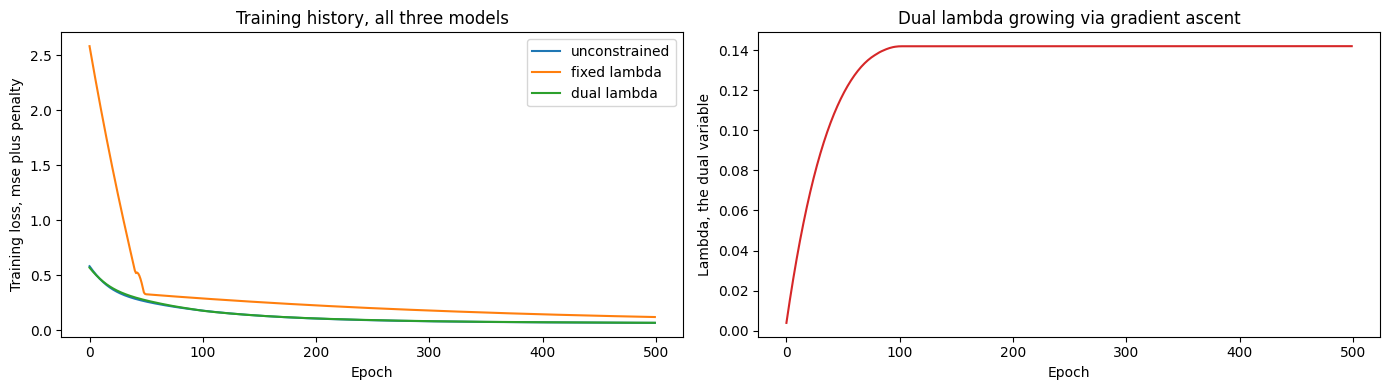

In [7]:
fig, axes = plt.subplots(1, 2, figsize=figsize)
axes[0].plot(history_unconstrained.history['loss'], label='unconstrained')
axes[0].plot(history_fixed.history['loss'], label='fixed lambda')
axes[0].plot(history_dual.history['loss'], label='dual lambda')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training loss, mse plus penalty')
axes[0].set_title('Training history, all three models')
axes[0].legend()

axes[1].plot(history_dual.history['alpha'], color='tab:red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Lambda, the dual variable')
axes[1].set_title('Dual lambda growing via gradient ascent')
plt.tight_layout()
plt.show()

**Read the right panel as the mechanism behind the left panel's result**

Lambda starts at zero, exactly as the lesson's update rule requires, and
grows only while the DIDI constraint is violated, which is also why its
curve is not smooth, every small uptick is an epoch where the network's
own weights had just pushed the constraint further out of bounds. It is
this adaptive growth, rather than a value fixed in advance at five, that
the lesson credits for the dual approach reaching a comparable DIDI with
less damage to accuracy, exactly the three fitted models evaluated in
the comparison below, nothing above retrains or replaces them

## Comparing All Three

Read this as a three way trade off, not a single winner. The
unconstrained model sets the accuracy ceiling and the DIDI floor is not
enforced at all. Both constrained versions should show a lower DIDI on
test, in exchange for some accuracy, and the lesson's own claim is that
the dual lambda version keeps more accuracy than the fixed lambda version
for a similar fairness level, since its penalty strength adapts during
training instead of being guessed once. Whether that holds here, on the real
chained RISK_SCORE and the smaller common subset described in section 1's
correction, is exactly what the table below is for.


In [8]:
from sklearn.metrics import r2_score, mean_absolute_error

def evaluate_fairness_method(model, X, df, name, split):
    pred = model.predict(X)
    r2 = r2_score(df['RISK_SCORE'].values, pred)
    mae = mean_absolute_error(df['RISK_SCORE'].values, pred)
    didi = du.compute_didi(df, pred, {'PTGENDER': (1, 2), 'PTEDUCAT_BUCKET': (0, 1)})
    print(f'{name:14s} {split:5s}  R2: {r2:6.3f}   DIDI: {didi:6.3f}   MAE: {mae:6.3f}')
    return {'approach': name, 'split': split, 'r2': r2, 'didi': didi, 'mae': mae}

fairness_rows = []
for name, model in [('unconstrained', unconstrained), ('fixed_lambda', fixed_lambda_model), ('dual_lambda', dual_lambda_model)]:
    fairness_rows.append(evaluate_fairness_method(model, X_train_scaled, lag_train_data, name, 'train'))
    fairness_rows.append(evaluate_fairness_method(model, X_test_scaled, lag_test_data, name, 'test'))

fairness_comparison_df = pd.DataFrame(fairness_rows)
fairness_comparison_df

unconstrained  train  R2:  0.220   DIDI:  0.102   MAE:  0.194
unconstrained  test   R2:  0.159   DIDI:  0.148   MAE:  0.198
fixed_lambda   train  R2: -0.381   DIDI:  0.045   MAE:  0.261
fixed_lambda   test   R2: -0.669   DIDI:  0.257   MAE:  0.274
dual_lambda    train  R2:  0.208   DIDI:  0.050   MAE:  0.195
dual_lambda    test   R2:  0.123   DIDI:  0.189   MAE:  0.202


        approach  split        r2      didi       mae
0  unconstrained  train  0.219716  0.101932  0.194355
1  unconstrained   test  0.158690  0.148134  0.197817
2   fixed_lambda  train -0.380918  0.045138  0.260804
3   fixed_lambda   test -0.668780  0.256515  0.274268
4    dual_lambda  train  0.208125  0.049695  0.194964
5    dual_lambda   test  0.122820  0.189395  0.201598

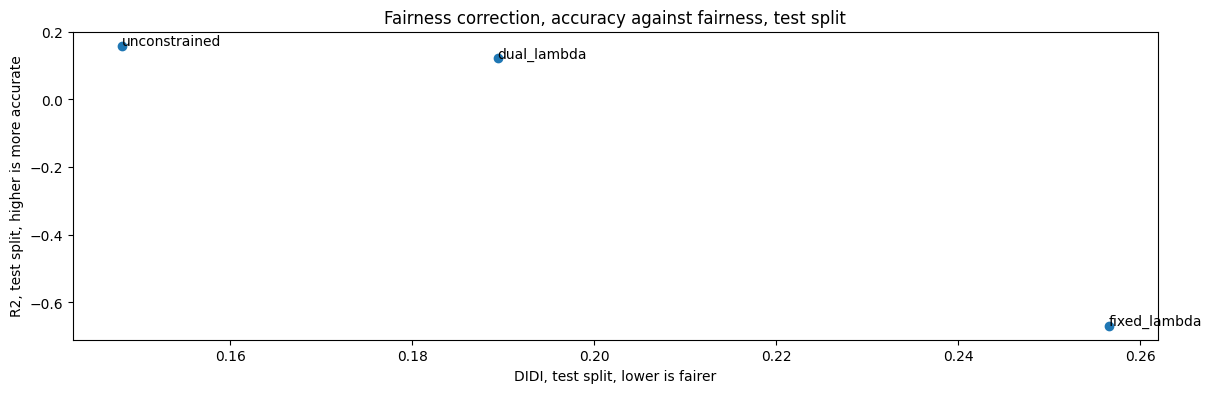

In [9]:
plt.figure(figsize=figsize)
test_rows = fairness_comparison_df[fairness_comparison_df['split'] == 'test']
plt.scatter(test_rows['didi'], test_rows['r2'])
for _, row in test_rows.iterrows():
    plt.annotate(row['approach'], (row['didi'], row['r2']))
plt.xlabel('DIDI, test split, lower is fairer')
plt.ylabel('R2, test split, higher is more accurate')
plt.title('Fairness correction, accuracy against fairness, test split')
plt.show()

## Predictions By Protected Group

The scatter above reads DIDI as a single number per model. 07-ciml's own
fairness plot, util.plot_pred_by_protected, instead shows the quantity
DIDI is built from directly, the average prediction inside each
protected group next to the overall average, which is what a reader
unfamiliar with the formula can actually look at and judge for
themselves. Shown here for the dual lambda model on the test split, the
version this notebook reports as its main result, next to the
unconstrained model for contrast.


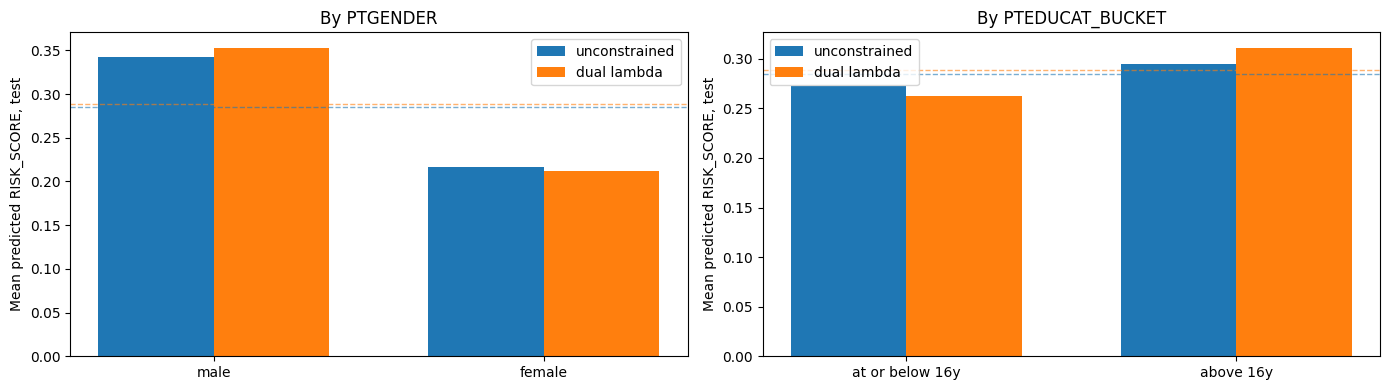

In [10]:
def group_means(df, pred, attribute, domain):
    overall = float(np.mean(pred))
    group_avgs = [float(np.mean(pred[df[attribute].to_numpy() == v])) for v in domain]
    return overall, group_avgs

unconstrained_test_pred = unconstrained.predict(X_test_scaled)
dual_test_pred = dual_lambda_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=figsize)
for ax, attribute, domain, labels in [
    (axes[0], 'PTGENDER', (1, 2), ('male', 'female')),
    (axes[1], 'PTEDUCAT_BUCKET', (0, 1), ('at or below 16y', 'above 16y')),
]:
    overall_u, groups_u = group_means(lag_test_data, unconstrained_test_pred, attribute, domain)
    overall_d, groups_d = group_means(lag_test_data, dual_test_pred, attribute, domain)
    x = np.arange(len(domain))
    width = 0.35
    ax.bar(x - width / 2, groups_u, width, label='unconstrained')
    ax.bar(x + width / 2, groups_d, width, label='dual lambda')
    ax.axhline(overall_u, color='tab:blue', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(overall_d, color='tab:orange', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Mean predicted RISK_SCORE, test')
    ax.set_title(f'By {attribute}')
    ax.legend()
plt.tight_layout()
plt.show()

**Each dashed line is that model's own overall average, the quantity
DIDI measures every group's distance from**

A model with zero disparate treatment would show both bars touching
their model's own dashed line in every panel, the unconstrained bars
sitting further from their line than the dual lambda bars do is the same
fact the DIDI numbers above already stated, shown here group by group
and attribute by attribute rather than folded into one summed figure

## How Much Would These Numbers Move

The R squared, DIDI, and mean absolute error above, for all three networks, each come from one fixed train and test split. bootstrap_ci resamples patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, scores the same already fitted network again on each resample without ever retraining it, retraining a Lagrangian network 400 times over would be far too slow to be practical here, and reads the 2.5th and 97.5th percentile as a 95 percent interval.

Read the test DIDI intervals against each other first, the trade off cell above already asks whether a lower DIDI is real or an accuracy give away, this adds whether that lower DIDI itself is real or could plausibly be noise from this particular patient sample.

unconstrained  train  R2 95% CI [ 0.128,  0.298]   DIDI 95% CI [ 0.036,  0.200]   MAE 95% CI [ 0.178,  0.212]
unconstrained  test   R2 95% CI [-0.063,  0.309]   DIDI 95% CI [ 0.056,  0.320]   MAE 95% CI [ 0.171,  0.232]
fixed_lambda   train  R2 95% CI [-0.646, -0.164]   DIDI 95% CI [ 0.017,  0.176]   MAE 95% CI [ 0.236,  0.284]
fixed_lambda   test   R2 95% CI [-1.247, -0.282]   DIDI 95% CI [ 0.076,  0.506]   MAE 95% CI [ 0.236,  0.328]
dual_lambda    train  R2 95% CI [ 0.114,  0.290]   DIDI 95% CI [ 0.020,  0.148]   MAE 95% CI [ 0.179,  0.213]
dual_lambda    test   R2 95% CI [-0.106,  0.285]   DIDI 95% CI [ 0.068,  0.363]   MAE 95% CI [ 0.174,  0.238]


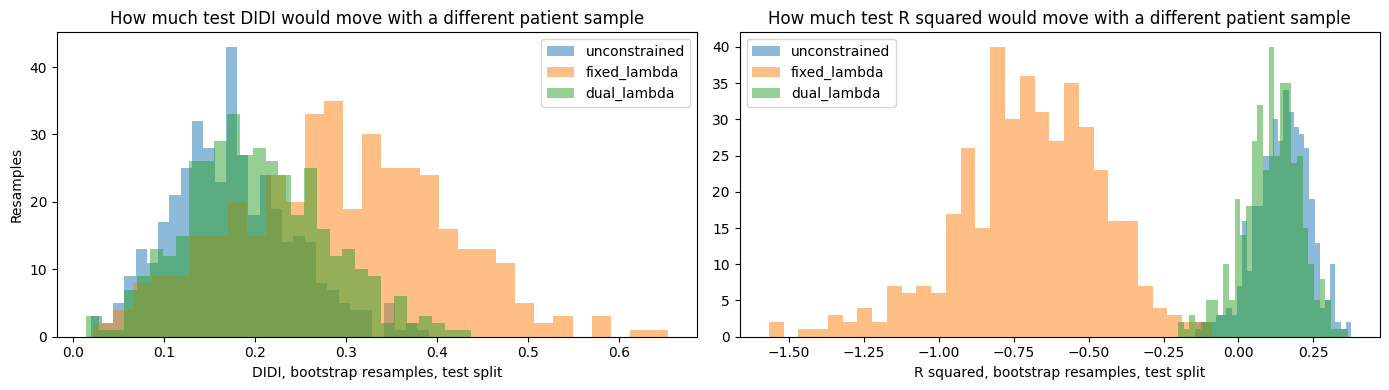

In [11]:
scaled_cols = [f'SCALED_{c}' for c in lagrangian_feature_cols]
lag_train_for_ci = lag_train_data.copy().reset_index(drop=True)
lag_train_for_ci[scaled_cols] = X_train_scaled
lag_test_for_ci = lag_test_data.copy().reset_index(drop=True)
lag_test_for_ci[scaled_cols] = X_test_scaled

# model.predict() carries enough per call overhead, a fresh data adapter
# built every time, that the 7200 calls three metrics, three networks,
# two splits, 400 resamples each would need take on the order of fifteen
# minutes. Calling the wrapped keras model directly in inference mode
# below is the same forward pass on the same trained weights, checked to
# return identical predictions, just without that repeated setup cost.
def fast_predict(model, X):
    X = np.asarray(X, dtype='float32')
    return np.asarray(model._model(X, training=False)).ravel()

def make_metric(model, value_key):
    def metric(d):
        X = d[scaled_cols].values
        pred = fast_predict(model, X)
        if value_key == 'r2':
            return r2_score(d['RISK_SCORE'].values, pred)
        if value_key == 'mae':
            return mean_absolute_error(d['RISK_SCORE'].values, pred)
        return du.compute_didi(d, pred, {'PTGENDER': (1, 2), 'PTEDUCAT_BUCKET': (0, 1)})
    return metric

models_by_name = [('unconstrained', unconstrained), ('fixed_lambda', fixed_lambda_model), ('dual_lambda', dual_lambda_model)]
splits_by_name = [('train', lag_train_for_ci), ('test', lag_test_for_ci)]

ci_results = {}
test_didi_samples = {}
test_r2_samples = {}
for name, model in models_by_name:
    for split, d in splits_by_name:
        r2_point, r2_lo, r2_hi, r2_samples = du.bootstrap_ci(d, make_metric(model, 'r2'), id_col='RID')
        mae_point, mae_lo, mae_hi, _ = du.bootstrap_ci(d, make_metric(model, 'mae'), id_col='RID')
        didi_point, didi_lo, didi_hi, didi_samples = du.bootstrap_ci(d, make_metric(model, 'didi'), id_col='RID')
        ci_results[(name, split)] = {'r2': (r2_lo, r2_hi), 'mae': (mae_lo, mae_hi), 'didi': (didi_lo, didi_hi)}
        print(f'{name:14s} {split:5s}  R2 95% CI [{r2_lo:6.3f}, {r2_hi:6.3f}]   '
              f'DIDI 95% CI [{didi_lo:6.3f}, {didi_hi:6.3f}]   MAE 95% CI [{mae_lo:6.3f}, {mae_hi:6.3f}]')
        if split == 'test':
            test_r2_samples[name] = r2_samples
            test_didi_samples[name] = didi_samples

fig, axes = plt.subplots(1, 2, figsize=figsize)

for name, _ in models_by_name:
    axes[0].hist(test_didi_samples[name], bins=30, alpha=0.5, label=name)
axes[0].set_xlabel('DIDI, bootstrap resamples, test split')
axes[0].set_ylabel('Resamples')
axes[0].set_title('How much test DIDI would move with a different patient sample')
axes[0].legend()

for name, _ in models_by_name:
    axes[1].hist(test_r2_samples[name], bins=30, alpha=0.5, label=name)
axes[1].set_xlabel('R squared, bootstrap resamples, test split')
axes[1].set_title('How much test R squared would move with a different patient sample')
axes[1].legend()

plt.tight_layout()
plt.show()

## Saving The Standardized Result

One row per split, appended to the shared
results/decision_support/approach_comparison.csv, read later by comparison.ipynb
alongside the other approaches. append_approach_result is
idempotent per approach and split, rerunning this notebook replaces its
own two rows rather than piling up duplicates. The confidence intervals from
the section above are logged alongside each row's own point estimates.

In [12]:
row_counts = {'train': len(lag_train_data), 'test': len(lag_test_data)}
COMMON_SUBSET_NOTE = 'Common subset, real chained RISK_SCORE, not the full native population.'
notes_map = {
    'unconstrained': f'No fairness constraint, this is the accuracy ceiling and DIDI floor for this comparison. {COMMON_SUBSET_NOTE}',
    'fixed_lambda': f'Fixed Lagrangian multiplier alpha=5.0, DIDI threshold {DIDI_THRESHOLD:.3f}. {COMMON_SUBSET_NOTE}',
    'dual_lambda': f'Learned Lagrangian multiplier via gradient ascent, trained alpha {dual_lambda_model.final_alpha:.3f}, DIDI threshold {DIDI_THRESHOLD:.3f}. {COMMON_SUBSET_NOTE}',
}

for row in fairness_rows:
    du.append_approach_result(
        results_path, approach=row['approach'], approach_group='fairness_correction',
        split=row['split'], n_rows=row_counts[row['split']],
        didi=row['didi'], r2=row['r2'], mae=row['mae'],
        ci=ci_results[(row['approach'], row['split'])],
        notes=notes_map[row['approach']],
    )
fairness_comparison_df


        approach  split        r2      didi       mae
0  unconstrained  train  0.219716  0.101932  0.194355
1  unconstrained   test  0.158690  0.148134  0.197817
2   fixed_lambda  train -0.380918  0.045138  0.260804
3   fixed_lambda   test -0.668780  0.256515  0.274268
4    dual_lambda  train  0.208125  0.049695  0.194964
5    dual_lambda   test  0.122820  0.189395  0.201598

**Read the numbers above plainly, not only as an abstract trade off.** On this population the fixed multiplier is not simply a different point on a trade off curve from the learned one, it loses on both axes at once, a lower test R2 and a higher test DIDI than the learned multiplier achieves on its own. The three way trade off framing from section 4 still holds in general, a different population or a different cost preference could favor a fixed multiplier chosen well, but on this real chained RISK_SCORE and this 1126 patient common subset, the learned multiplier is the one worth reporting as this notebook's main result, not a coin flip between two valid options. See comparison.ipynb for how it stacks up against the other approaches, kept out of this notebook so it stays correct even if this one is rerun on its own, with different cost parameters or a different biomarker set.